# Main Figures — Boxplots by Experimental Group

Produces four boxplot figures comparing the three experimental groups  
(No Resource, PDF, ChatGPT) across primary outcome domains.

**Input:** `../data/processed/survey_clean.csv`  
**Output:** `../figures/main_boxplots/fig1_knowledge_outcomes.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig2_pct_correct.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig3_completion_time.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig4_self_assessment.[png|pdf]`

| Figure | Variables | y-axis scale |
|--------|-----------|-------------|
| 1 | n_correct, n_incorrect, n_not_sure | Count (0–12) |
| 2 | pct_correct_of_attempted | Percent (0–100) |
| 3 | duration_min | Minutes |
| 4 | self_knowledge_tdi, self_confidence_avulsion, self_confidence_fracture, self_confidence_mean | Rating (0–10) |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Theme ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="white", font_scale=1.4)

# ── Constants ─────────────────────────────────────────────────────────────────
HUE_ORDER = ["No Resource", "PDF", "ChatGPT"]
HUE_PALETTE = {"No Resource": "#F8766D", "PDF": "#CD9600", "ChatGPT": "#00A9FF"}

FLIERPROPS = dict(marker="", markersize=0)  # hide default outlier markers
STRIP_KWS  = dict(jitter=True, alpha=0.6, dodge=True, linewidth=0.5)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path("../data/processed/survey_clean.csv")
OUT_DIR   = Path("../figures/main_boxplots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df["group_label"] = pd.Categorical(df["group_label"], categories=HUE_ORDER, ordered=True)

print(f"Loaded {len(df)} rows. Groups: {df['group_label'].value_counts().to_dict()}")
df[["n_correct", "n_incorrect", "n_not_sure",
    "pct_correct_of_attempted", "duration_min",
    "self_knowledge_tdi", "self_confidence_avulsion",
    "self_confidence_fracture", "self_confidence_mean"]].describe()

Loaded 18 rows. Groups: {'No Resource': 7, 'ChatGPT': 6, 'PDF': 5}


,n_correct,n_incorrect,n_not_sure,pct_correct_of_attempted,duration_min,self_knowledge_tdi,self_confidence_avulsion,self_confidence_fracture,self_confidence_mean
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,8.222222,3.777778,0.444444,68.522222,19.357222,4.111111,4.722222,4.555556,4.462222
std,1.832888,1.832888,1.149026,15.270408,29.290747,2.928338,3.139980,3.110177,2.958172
min,5.000000,1.000000,0.000000,41.700000,2.970000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,2.250000,0.000000,58.300000,6.032500,2.000000,2.000000,2.250000,1.835000
50%,8.000000,4.000000,0.000000,66.700000,8.260000,3.000000,5.500000,5.000000,4.165000
75%,9.750000,5.000000,0.000000,81.225000,14.692500,6.750000,7.000000,6.000000,6.330000
max,11.000000,7.000000,4.000000,91.700000,107.050000,9.000000,9.000000,10.000000,9.330000


## Figure 1 — Knowledge Outcomes by Group

Three x-axis categories: Total Correct, Total Incorrect, Total Not Sure.  
This figure carries the shared legend for all four figures.

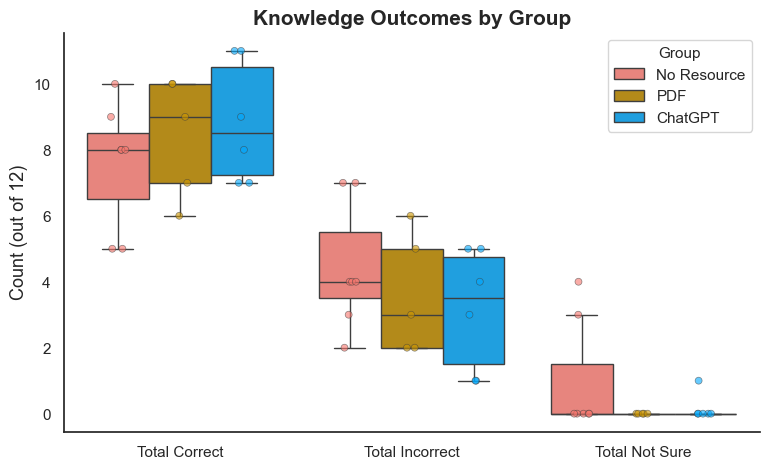

Saved fig1_knowledge_outcomes


In [2]:
# Melt to long format
fig1_vars = {
    "n_correct":   "Total Correct",
    "n_incorrect": "Total Incorrect",
    "n_not_sure":  "Total Not Sure",
}
df_fig1 = (
    df[["group_label"] + list(fig1_vars)]
    .melt(id_vars="group_label", var_name="_col", value_name="count")
    .assign(metric=lambda x: x["_col"].map(fig1_vars))
)
df_fig1["metric"] = pd.Categorical(
    df_fig1["metric"], categories=list(fig1_vars.values()), ordered=True
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig1, x="metric", y="count", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig1, x="metric", y="count", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Knowledge Outcomes by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Count (out of 12)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)

# Keep only one legend (strip duplicates the boxplot legend)
handles, labels = ax.get_legend_handles_labels()
n_groups = len(HUE_ORDER)
legend = ax.legend(
    handles[:n_groups], labels[:n_groups],
    title="Group", loc="upper right",
    fontsize=11, title_fontsize=11,
)

plt.tight_layout()
fig.savefig(OUT_DIR / "fig1_knowledge_outcomes.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig1_knowledge_outcomes.pdf", bbox_inches="tight")
plt.show()
print("Saved fig1_knowledge_outcomes")

## Figure 2 — Percent Correct of Attempted by Group

Single x-axis category; y-axis is 0–100 % (different scale from Figure 1).

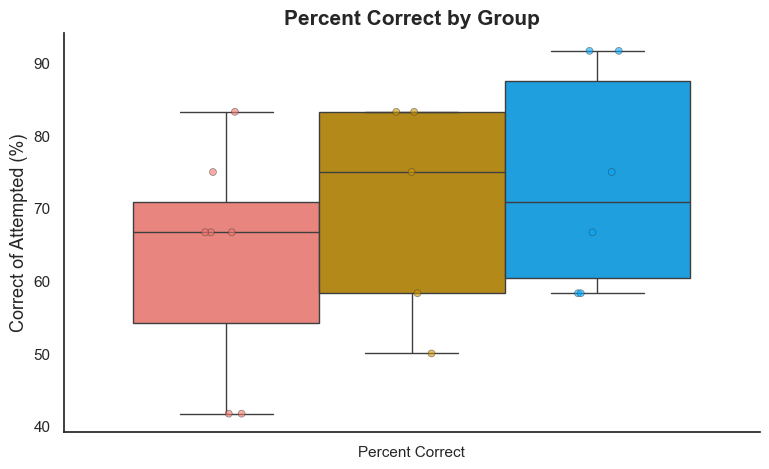

Saved fig2_pct_correct


In [3]:
df_fig2 = df[["group_label", "pct_correct_of_attempted"]].copy()
df_fig2["metric"] = "Percent Correct"

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig2, x="metric", y="pct_correct_of_attempted", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig2, x="metric", y="pct_correct_of_attempted", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Percent Correct by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Correct of Attempted (%)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig2_pct_correct.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig2_pct_correct.pdf", bbox_inches="tight")
plt.show()
print("Saved fig2_pct_correct")

## Figure 3 — Completion Time by Group

Single x-axis category; y-axis in minutes.

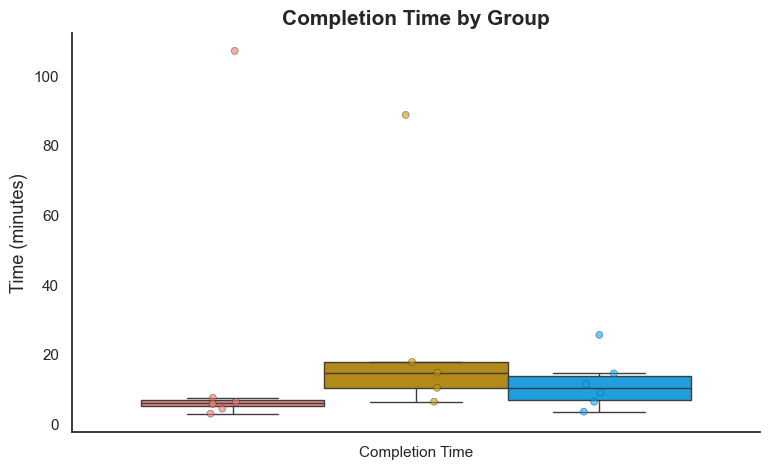

Saved fig3_completion_time


In [4]:
df_fig3 = df[["group_label", "duration_min"]].copy()
df_fig3["metric"] = "Completion Time"

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig3, x="metric", y="duration_min", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig3, x="metric", y="duration_min", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Completion Time by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Time (minutes)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig3_completion_time.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig3_completion_time.pdf", bbox_inches="tight")
plt.show()
print("Saved fig3_completion_time")

## Figure 4 — Self-Assessment by Group

Four x-axis categories: TDI Knowledge, Avulsion Confidence, Fracture Confidence,  
Average Self-Assessment. y-axis is 0–10 rating scale.

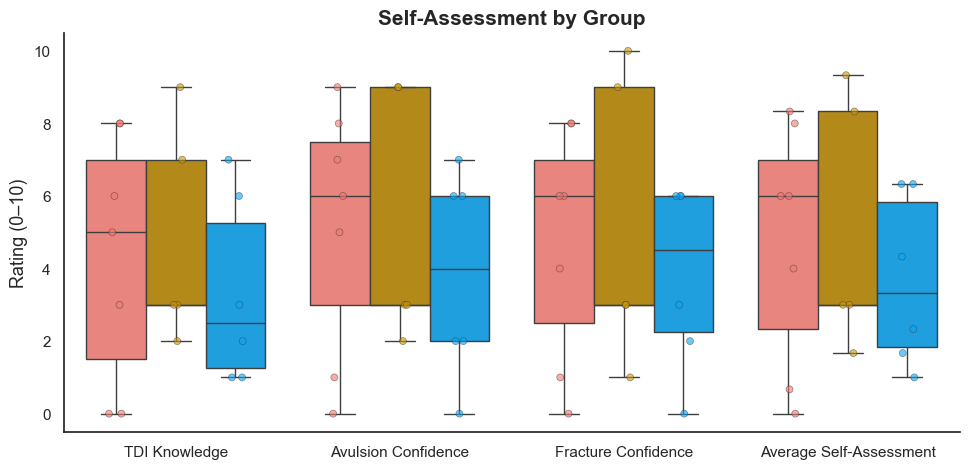

Saved fig4_self_assessment


In [5]:
fig4_vars = {
    "self_knowledge_tdi":        "TDI Knowledge",
    "self_confidence_avulsion":  "Avulsion Confidence",
    "self_confidence_fracture":  "Fracture Confidence",
    "self_confidence_mean":      "Average Self-Assessment",
}
df_fig4 = (
    df[["group_label"] + list(fig4_vars)]
    .melt(id_vars="group_label", var_name="_col", value_name="rating")
    .assign(metric=lambda x: x["_col"].map(fig4_vars))
)
df_fig4["metric"] = pd.Categorical(
    df_fig4["metric"], categories=list(fig4_vars.values()), ordered=True
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_fig4, x="metric", y="rating", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig4, x="metric", y="rating", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Self-Assessment by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Rating (0–10)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig4_self_assessment.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig4_self_assessment.pdf", bbox_inches="tight")
plt.show()
print("Saved fig4_self_assessment")